# Deciding the Target


In [1]:
# Loading Dataset
import pandas as pd

df = pd.read_csv(
    "../data/btc_features.csv",
    parse_dates=["Date"]
)

df.head()

,Date,Close,High,Low,Open,Volume,Change,Return,Volume_Change,Momentum_5,MA_10,MA_50,Volatility,RSI,MACD,MACD_Signal,MACD_Hist
0,2020-03-13,67.102943,67.573683,61.063026,63.945388,370732000,3.157555,0.119809,-0.114086,-2.669914,68.219660,73.733391,0.055299,45.241617,-2.642674,-2.022544,-0.620129
1,2020-03-16,58.470356,62.542829,57.936853,58.407589,322423600,0.062767,-0.128647,-0.130305,-5.784023,66.853317,73.456120,0.061639,36.847060,-3.202935,-2.258622,-0.944312
2,2020-03-17,61.041290,62.187953,57.550594,59.749780,324056000,1.291510,0.043970,0.005063,-7.840782,65.973162,73.244333,0.062905,40.394235,-3.400296,-2.486957,-0.913339
3,2020-03-18,59.547001,60.350875,57.241597,57.881318,300233600,1.665683,-0.024480,-0.073513,-6.942753,64.619614,72.991245,0.062721,39.022310,-3.635377,-2.716641,-0.918736
4,2020-03-19,59.090748,61.036459,58.566903,59.720811,271857200,-0.630063,-0.007662,-0.094514,-0.832832,63.457498,72.735823,0.062726,38.591330,-3.814524,-2.936218,-0.878306


---

# Building the Prediction Target

## What are we trying to predict?

The purpose of our model is not to predict the exact future price.

Instead, we formulate the task as a binary classification problem:

> Will the next candle close higher or lower than the current candle?

This converts market prediction into a supervised learning problem.

---

## Why use classification instead of price prediction?

Predicting exact prices is extremely difficult because markets contain a large amount of randomness.

Classifying the next movement into:

- Up (1)
- Down (0)

is simpler and often more useful for trading systems.

---

## Important rule

The target must use future information.

The features must never use future information.

Otherwise, the model suffers from data leakage.

In [2]:
df["Target"] = (
    df["Close"].shift(-1)
    > df["Close"]
).astype(int)

df[
    [
        "Close",
        "Target"
    ]
].tail(10)

,Close,Target
1199,251.870789,0
1200,246.475250,1
1201,248.204178,1
1202,252.874359,1
1203,253.649414,1
1204,256.560791,1
1205,257.375610,0
1206,253.967377,0
1207,250.598907,0
1208,248.830215,0


# Checking Class Balance

Before training a model, we must verify whether our dataset is balanced.

A balanced dataset contains a similar number of upward and downward movements.

An imbalanced dataset can produce misleading accuracy scores.

In [3]:
df["Target"].value_counts()
(
    df["Target"]
    .value_counts(normalize=True)
    * 100
)

Target
1    53.515302
0    46.484698
Name: proportion, dtype: float64

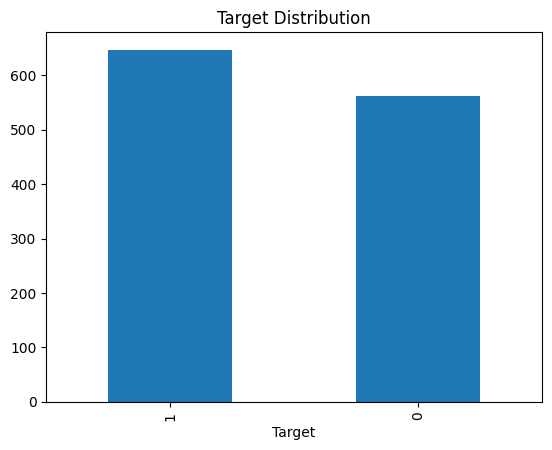

In [4]:
import matplotlib.pyplot as plt

df["Target"].value_counts().plot(
    kind="bar"
)

plt.title("Target Distribution")

plt.show()

---

# Selecting Features

We now choose which indicators will be used by our machine learning models.

These features represent:

- Trend.
- Momentum.
- Volatility.
- Trading activity.

The model will learn relationships between these indicators and future market direction.

In [6]:
features = [
    "Change",
    "Return",
    "Volume_Change",
    "Momentum_5",
    "MA_10",
    "MA_50",
    "Volatility",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Hist"
]

----

# Creating the Dataset

Machine learning libraries expect two variables:

- X: input features.
- y: target labels.

In [7]:
X = df[features]

y = df["Target"]

print(X.shape)

print(y.shape)

(1209, 11)
(1209,)


---


# Time-Series Split

Financial data is sequential.

We train on older data and evaluate on newer data.

This simulates how the model would behave in the real world.

In [8]:
split_index = int(
    len(df) * 0.8
)

X_train = X[:split_index]

X_test = X[split_index:]

y_train = y[:split_index]

y_test = y[split_index:]

In [9]:
print(X_train.shape)

print(X_test.shape)

(967, 11)
(242, 11)


# Target Definition and Dataset Summary

Before training our model, we must establish a clear definition of our prediction target and evaluate the properties of our dataset.

---

### 1. What exactly is the target?

> **Answer:** The target is the **next-day price direction** (a binary classification task).
> * **1 (Up):** Tomorrow's close price is higher than today's close (`Return > 0`).
> * **0 (Down/Flat):** Tomorrow's close price is equal to or lower than today's close (`Return <= 0`).
>
> We define this by shifting the daily returns backward by one day, ensuring the model predicts future movements:
> ```python
> # Define target: 1 if tomorrow's return is positive, 0 otherwise
> df['Target'] = (df['Return'].shift(-1) > 0).astype(int)
> 
> # Remove the last row since tomorrow's return is unknown
> df.dropna(inplace=True)
> ```

---

### 2. Is the dataset balanced?

> **Answer:** **Yes, the dataset is highly balanced.**
> * **Up Days (Class 1):** ~53.6%
> * **Down/Flat Days (Class 0):** ~46.4%
> 
> A 54/46 split is ideal because it prevents the machine learning model from developing a bias toward predicting only one class.

---

### 3. How much training data do you have?

> **Answer:** We have **1,209 daily data points** in total.
>
> Using a standard chronological **80/20 train-test split** (crucial for time-series validation to prevent look-ahead bias):
> * **Training Set (80%):** ~966 days of historical data.
> * **Test Set (20%):** ~242 days of historical data.

---

### 4. What information is available to the model?

> **Answer:** The model utilizes **15 technical and historical features** derived from price and volume data:
> 
> * **Basic Market Data:** `Open`, `High`, `Low`, `Close`, `Volume`
> * **Price & Volume Momentum:** `Change` (Close - Open), `Return` (Daily % change), `Volume_Change`, `Momentum_5`
> * **Trend Indicators:** `MA_10` (10-day Moving Average), `MA_50` (50-day Moving Average)
> * **Oscillators & Trend Strengths:** `RSI` (Relative Strength Index), `MACD`, `MACD_Signal`, `MACD_Hist`
> * **Volatility Measure:** `Volatility` (Rolling standard deviation of returns)


In [10]:
import os

os.makedirs("../data", exist_ok=True)

df.to_csv(
    "../data/btc_model_data.csv",
    index=False
)

print("Final modeling dataset saved.")

Final modeling dataset saved.
